In [1]:
# basics libraries
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters

# Libraries for maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Units libraries
import metpy.calc as mpcalc
from metpy.units import units

# Time libraries
import matplotlib.dates as mdates

# Plots libraries
import matplotlib.colors as mcolors
import os

# for altimeter or buoys analysis
from scipy.spatial import cKDTree

Define region of interest

In [2]:
Region_plots = "Mediterennean sea"
Region_saves = "Mediterrenean sea"
Months_list = ["January", "February", "March", "April", "May", "June", "Jule", "August", "September", "October", "November", "December"]
Range_of_regions = {"range" : [-10,37,30,48]}

Read matched datasets (altimeter)

In [3]:
df_all_with_cur = pd.read_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Altimeter evaluation//datasets//with_cur//matched_dataset_with_cur (Med).csv")
df_all_no_cur = pd.read_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Altimeter evaluation//datasets//no_cur//matched_dataset_no_cur (Med).csv")
df_all_no_cur

,variable,platform_id,platform_type,time,longitude,latitude,depth,pressure,is_depth_from_producer,hs_altimeter,value_qc,institution,doi,product_doi,hs_model_no_cur
0,VAVH,CFOSAT,SAT,2020-01-01 05:42:24,26.893005,33.364,-0.0,NaN,1,0.961,1,CLS,NaN,https://doi.org/10.48670/moi-00176,2.431569
1,VAVH,CFOSAT,SAT,2020-01-01 05:42:26,26.863007,33.245,-0.0,NaN,1,1.029,1,CLS,NaN,https://doi.org/10.48670/moi-00176,2.429833
2,VAVH,CFOSAT,SAT,2020-01-01 05:42:28,26.829987,33.113,-0.0,NaN,1,1.206,1,CLS,NaN,https://doi.org/10.48670/moi-00176,2.418065
3,VAVH,CFOSAT,SAT,2020-01-01 05:42:29,26.813995,33.054,-0.0,NaN,1,1.041,1,CLS,NaN,https://doi.org/10.48670/moi-00176,2.412024
4,VAVH,CFOSAT,SAT,2020-01-01 05:42:31,26.782990,32.928,-0.0,NaN,1,0.925,1,CLS,NaN,https://doi.org/10.48670/moi-00176,2.381408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83256,VAVH,CFOSAT,SAT,2020-12-31 07:02:22,7.803985,37.284,-0.0,NaN,1,2.032,1,CLS,NaN,https://doi.org/10.48670/moi-00176,2.213587
83257,VAVH,CFOSAT,SAT,2020-12-31 07:02:23,7.786011,37.218,-0.0,NaN,1,1.918,1,CLS,NaN,https://doi.org/10.48670/moi-00176,2.117807
83258,VAVH,CFOSAT,SAT,2020-12-31 07:02:24,7.768005,37.152,-0.0,NaN,1,1.825,1,CLS,NaN,https://doi.org/10.48670/moi-00176,1.968831
83259,VAVH,CFOSAT,SAT,2020-12-31 07:02:25,7.752014,37.093,-0.0,NaN,1,1.775,1,CLS,NaN,https://doi.org/10.48670/moi-00176,1.781910


Monthly altimeter datasets

In [4]:
# Convert altimeter timestamps to pandas datetime format.
df_all_no_cur['time'] = pd.to_datetime(df_all_no_cur['time'])
df_all_with_cur['time'] = pd.to_datetime(df_all_with_cur['time'])

# prepare empty arrays for monthly datasets
df_months_no_cur,df_months_with_cur = [None]*12, [None]*12
months = ['2020-01', '2020-02', '2020-03', '2020-04', '2020-05', '2020-06', '2020-07', '2020-08', '2020-09', '2020-10', '2020-11', '2020-12']

# build monthly datasets
for i in range(0,12): 
    df_months_no_cur[i] = df_all_no_cur[df_all_no_cur['time'].dt.to_period('M') == months[i]]
    df_months_with_cur[i] = df_all_with_cur[df_all_with_cur['time'].dt.to_period('M') == months[i]]
df_months_with_cur[11]

,variable,platform_id,platform_type,time,longitude,latitude,depth,pressure,is_depth_from_producer,hs_altimeter,value_qc,institution,doi,product_doi,hs_model_with_cur
74007,VAVH,CFOSAT,SAT,2020-12-01 06:24:01,18.546997,42.252,-0.0,NaN,1,0.842,1,CLS,NaN,https://doi.org/10.48670/moi-00176,0.315057
74008,VAVH,CFOSAT,SAT,2020-12-01 06:24:02,18.528992,42.192,-0.0,NaN,1,0.822,1,CLS,NaN,https://doi.org/10.48670/moi-00176,0.350298
74009,VAVH,CFOSAT,SAT,2020-12-01 06:24:03,18.510986,42.133,-0.0,NaN,1,0.843,1,CLS,NaN,https://doi.org/10.48670/moi-00176,0.404317
74010,VAVH,CFOSAT,SAT,2020-12-01 06:24:04,18.490997,42.067,-0.0,NaN,1,0.903,1,CLS,NaN,https://doi.org/10.48670/moi-00176,0.465685
74011,VAVH,CFOSAT,SAT,2020-12-01 06:24:05,18.471008,42.002,-0.0,NaN,1,0.961,1,CLS,NaN,https://doi.org/10.48670/moi-00176,0.531346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83256,VAVH,CFOSAT,SAT,2020-12-31 07:02:22,7.803985,37.284,-0.0,NaN,1,2.032,1,CLS,NaN,https://doi.org/10.48670/moi-00176,1.967521
83257,VAVH,CFOSAT,SAT,2020-12-31 07:02:23,7.786011,37.218,-0.0,NaN,1,1.918,1,CLS,NaN,https://doi.org/10.48670/moi-00176,1.916219
83258,VAVH,CFOSAT,SAT,2020-12-31 07:02:24,7.768005,37.152,-0.0,NaN,1,1.825,1,CLS,NaN,https://doi.org/10.48670/moi-00176,1.905314
83259,VAVH,CFOSAT,SAT,2020-12-31 07:02:25,7.752014,37.093,-0.0,NaN,1,1.775,1,CLS,NaN,https://doi.org/10.48670/moi-00176,1.852888


QQ-plot fuction (from metocean stats)

In [5]:
from metocean_stats import stats
import scipy.stats as st
def plot_scatter(df, var1, var2,
                 var1_units='m', var2_units='m',
                 title=' ',
                 regression_line='effective-variance',
                 qqplot=True, density=True,
                 output_file='scatter_plot.png',
                 annotation_position='bottom-right'):
    x = df[var1].values
    y = df[var2].values

    fig, ax = plt.subplots()

    # --------------------------
    # Scatter / Density plot
    # --------------------------
    if not density:
        ax.scatter(x, y, marker='.', s=10, c='g')
    else:
        #plt.hist2d(x, y, bins=50, cmap='hot', cmin=1)
        #plt.colorbar()
        h = ax.hist2d(x, y, bins=50, cmap='hot', cmin=1)
        fig.colorbar(h[3], ax=ax)    # h[3] is the QuadMesh

    dmin, dmax = np.min([x, y]) * 0.9, np.max([x, y]) * 1.05
    diag = np.linspace(dmin, dmax, 1000)
    ax.plot(diag, diag, color='r', linestyle='--')

    ax.set_aspect('equal')
    ax.set_xlim([0, dmax])
    ax.set_ylim([0, dmax])

    # --------------------------
    # QQ Plot
    # --------------------------
    if qqplot:
        percs = np.linspace(0, 100, 101)
        qn_x = np.nanpercentile(x, percs)
        qn_y = np.nanpercentile(y, percs)
        ax.scatter(qn_x, qn_y, marker='.', s=80, c='b')

    # --------------------------
    # Regression line
    # --------------------------
    if regression_line == 'least-squares':
        slope = st.linregress(x, y).slope
        intercept = st.linregress(x, y).intercept

    elif regression_line == 'mean-slope':
        slope = np.mean(y) / np.mean(x)
        intercept = 0

    elif regression_line == 'effective-variance':
        slope = stats.linfitef(x, y)[0]
        intercept = stats.linfitef(x, y)[1]

    else:
        slope = None
        intercept = None

    if slope is not None:
        if intercept > 0:
            label = f"$y = {slope:.2f}x + {intercept:.2f}$"
        elif intercept < 0:
            label = f"$y = {slope:.2f}x - {abs(intercept):.2f}$"
        else:
            label = f"$y = {slope:.2f}x$"

        ax.plot(x, slope * x + intercept, 'k--', label=label)
        ax.legend(loc='best')

    # --------------------------
    # Statistics
    # --------------------------
    rmse = np.sqrt(((y - x) ** 2).mean())
    bias = np.mean(y - x)
    mae = np.mean(np.abs(y - x))
    corr = np.corrcoef(y, x)[0][1]
    si = np.std(x - y) / np.mean(x)
    mean_mod = np.mean(x)
    mean_obs = np.mean(y)
    std_mod = np.std(x)
    std_obs = np.std(y)

    stats_text = (
        f"rmse = {rmse:.3f}"
        f"\nbias = {bias:.3f}"
        f"\nmae = {mae:.3f}"
        f"\ncorr = {corr:.3f}"
        f"\nsi = {si:.3f}"
        f"\nMean Mod = {mean_mod:.3f}"
        f"\nMean Obs = {mean_obs:.3f}"
        f"\nStd Mod = {std_mod:.3f}"
        f"\nStd Obs = {std_obs:.3f}"
    )

    # --------------------------
    # Annotation placement
    # --------------------------
    positions = {
        'bottom-right': (0.98, 0.02),
        'bottom-left':  (0.02, 0.02),
        'top-right':    (0.98, 0.98),
        'top-left':     (0.02, 0.98)
    }

    xy = positions.get(annotation_position, (0.98, 0.02))

    ax.annotate(
        stats_text,
        xy=xy,
        xycoords='axes fraction',
        ha='right' if 'right' in annotation_position else 'left',
        va='top' if 'top' in annotation_position else 'bottom',
        fontsize=10,
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
    )

    # --------------------------
    # Labels & title
    # --------------------------
    ax.set_xlabel(f"{var1}[{var1_units}]", fontsize=15)
    ax.set_ylabel(f"{var2}[{var2_units}]", fontsize=15)

    ax.set_title(
         (f"{title}, N={np.count_nonzero(~np.isnan(x)):.0f}"),
        fontsize=15
    )

    ax.grid()

    # --------------------------
    # Save figure
    # --------------------------
    if output_file:
        fig.savefig(output_file)

    return None


Plots style

In [6]:
def style_axis(ax, month_labels, months_plot, title=None,ylabel=None):
    # format x-axis as dates
    ax.set_xticks(months_plot, month_labels)
    ax.set_xlabel("Time", fontsize=18)
    #ax.set_ylabel("Statistics")
    #ax.set_title(f"Statistics (with_cur, {Region_plots}) – Time Series")
    ax.grid(True)
    ax.legend(loc='best', ncol=2, frameon=True, fontsize=14)
    
    if title:
        ax.set_title(title, fontsize=18)

    if ylabel:
        ax.set_ylabel(ylabel, fontsize=12)
    return ax

Compute an adaptive percentile range for plotting, depending on the data distribution.

In [7]:
import numpy as np
from scipy.stats import skew, kurtosis, normaltest

def adaptive_percentile_range(data):
    """Compute an adaptive percentile range for plotting, 
    depending on the data distribution.
    Returns (lower_bound, upper_bound, coverage_percent)."""
    data = np.asarray(data)
    data = data[np.isfinite(data)]  # remove NaNs and infs

    # Basic distribution metrics
    s = skew(data)
    k = kurtosis(data)
    stat, pval = normaltest(data)  # normality test (null: normal)

    # Start with default 90% range
    coverage = 10.0
    
    # Adjust for heavy tails or skewed data
    if pval < 0.05:  # not normal
        if abs(s) > 1 or k > 3:       # strongly skewed or heavy tails
            #coverage = 10.0
            coverage = 90.0
        elif abs(s) > 0.5 or k > 1:   # moderately skewed
            #coverage = 10.0
            coverage = 93.0
    else:
        #coverage = 10.0  # almost normal, show more of the data
        coverage = 98.0  # almost normal, show more of the data

    lower = (100 - coverage) / 2
    upper = 100 - lower
    bounds = np.percentile(data, [lower, upper])

    return bounds, coverage


Timeseries of validation metrics (altimeter merged dataset)

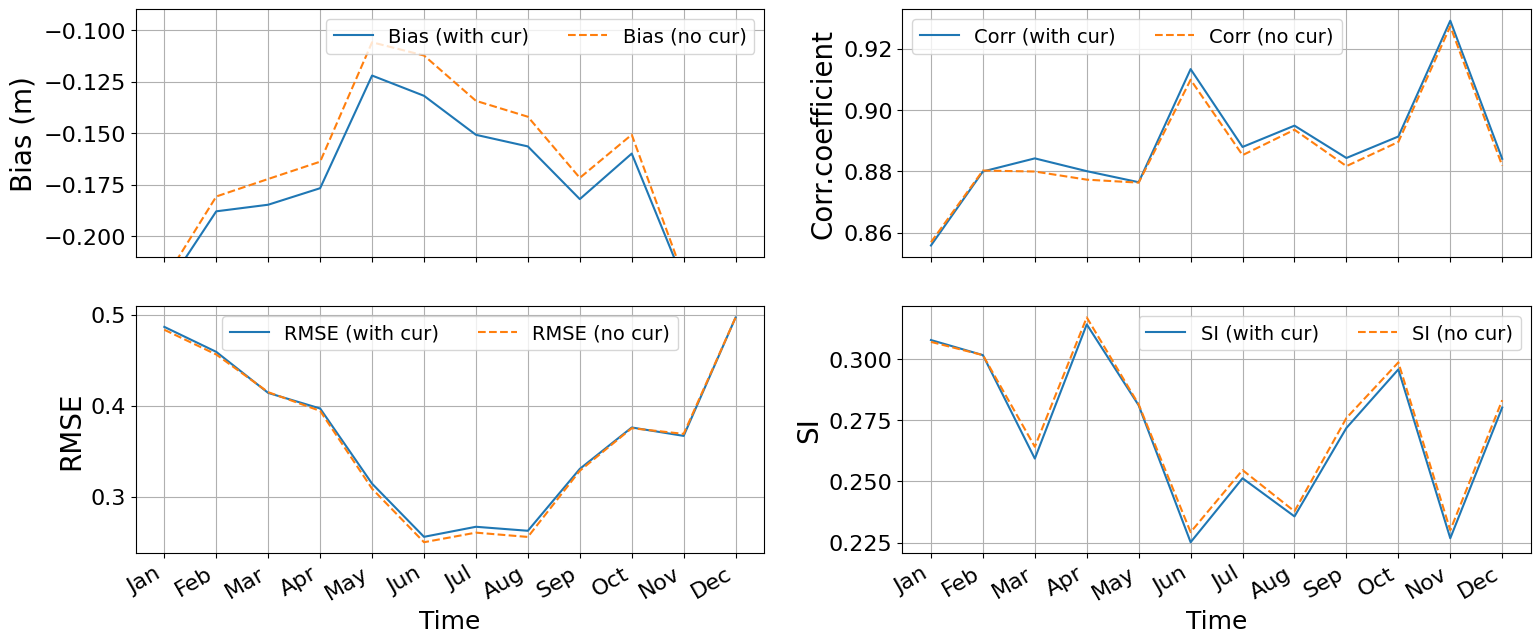

In [ ]:
import calendar

rmse_no,bias_no,corr_no,si_no = [None]*12,[None]*12,[None]*12,[None]*12
rmse_with,bias_with,corr_with,si_with = [None]*12,[None]*12,[None]*12,[None]*12

months = range(1, 13)

month_labels = [calendar.month_abbr[m] for m in months]

for i in range(0,12):

    # with currents
    y = df_months_with_cur[i]["hs_model_with_cur"].values
    x = df_months_with_cur[i]["hs_altimeter"].values

    rmse_with[i] = np.sqrt(np.mean((y - x) ** 2))
    bias_with[i] = np.mean(y - x)
    corr_with[i] = np.corrcoef(y, x)[0, 1]
    si_with[i]   = np.std(x - y) / np.mean(x)

    # no currents
    m = df_months_no_cur[i]["hs_model_no_cur"].values
    k = df_months_no_cur[i]["hs_altimeter"].values

    rmse_no[i] = np.sqrt(np.mean((m - k) ** 2))
    bias_no[i] = np.mean(m - k)
    corr_no[i] = np.corrcoef(m, k)[0, 1]
    si_no[i]   = np.std(k - m) / np.mean(k)

fig, axes = plt.subplots(2,2,figsize=(18,8))
axes = axes.flatten()  # flatten to a 1D array of length 10
ax1, ax2, ax3, ax4 = axes

plt.subplots_adjust(wspace=0.22)  # increase horizontal spacing

ax1.plot(months, bias_with, label="Bias (with cur)", linewidth = "1.5")
ax1.plot(months, bias_no, linestyle='--', label="Bias (no cur)", linewidth = "1.5")
style_axis(ax1, month_labels, months, ylabel="Bias (m)")
ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16)
ax1.set_ylabel("Bias (m)", fontsize=20)
ax1.set_ylim(-0.21,-0.09)

ax2.plot(months, corr_with, label="Corr (with cur)", linewidth = "1.5")
ax2.plot(months, corr_no, linestyle='--', label="Corr (no cur)", linewidth = "1.5")
style_axis(ax2, month_labels, months, ylabel="Corr. coefficient")
ax2.set_ylabel("Corr.coefficient", fontsize=20)
ax2.tick_params(axis='x', labelsize=16)
ax2.tick_params(axis='y', labelsize=16)

ax3.plot(months, rmse_with, label="RMSE (with cur)", linewidth = "1.5")
ax3.plot(months, rmse_no, linestyle='--', label="RMSE (no cur)", linewidth = "1.5")
style_axis(ax3, month_labels, months, ylabel="RMSE")
ax3.set_ylabel("RMSE", fontsize=20)
ax3.tick_params(axis='x', labelsize=16)
ax3.tick_params(axis='y', labelsize=16)

ax4.plot(months, si_with, label="SI (with cur)", linewidth = "1.5")
ax4.plot(months, si_no, linestyle='--', label="SI (no cur)", linewidth = "1.5")
style_axis(ax4, month_labels, months, ylabel="SI")
ax4.set_ylabel("SI", fontsize=20)
ax4.tick_params(axis='x', labelsize=16)
ax4.tick_params(axis='y', labelsize=16)

# 2. Use AutoDateLocator to avoid too many labels
locator = mdates.AutoDateLocator(minticks=15, maxticks=20)

# Let matplotlib automatically choose tick spacing
fig.autofmt_xdate()

#plt.tight_layout()
plt.show()


Bias timeseries (comparison between the two runs)

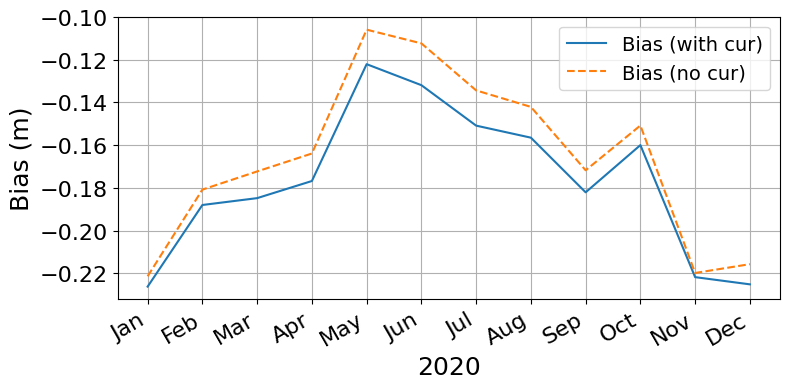

In [ ]:
import calendar

bias_no, bias_with = [None]*12, [None]*12

months = range(1, 13)

month_labels = [calendar.month_abbr[m] for m in months]

for i in range(0,12):

    # with currents
    y = df_months_with_cur[i]["hs_model_with_cur"].values
    x = df_months_with_cur[i]["hs_altimeter"].values

    bias_with[i] = np.mean(y - x)

    # no currents
    m = df_months_no_cur[i]["hs_model_no_cur"].values
    k = df_months_no_cur[i]["hs_altimeter"].values

    bias_no[i] = np.mean(m - k)

fig = plt.figure(figsize=(8, 4))

plt.rcParams.update({"axes.titlesize": 9,"axes.labelsize": 14})

plt.plot(months, bias_with, label="Bias (with cur)", linewidth = "1.5")
plt.plot(months, bias_no, linestyle='--', label="Bias (no cur)", linewidth = "1.5")
plt.xticks(months, month_labels, fontsize=16)
plt.xlabel("2020", fontsize=18)
plt.ylabel("Bias (m)", fontsize=18)
plt.yticks(fontsize=16)
plt.grid(True)
plt.legend(loc='best', ncol=1, fontsize=14)

# 2. Use AutoDateLocator to avoid too many labels
locator = mdates.AutoDateLocator(minticks=15, maxticks=20)

# Let matplotlib automatically choose tick spacing
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

Timeseries of validation metrics (merged altimeter matched dataset - Mediterranean sea)

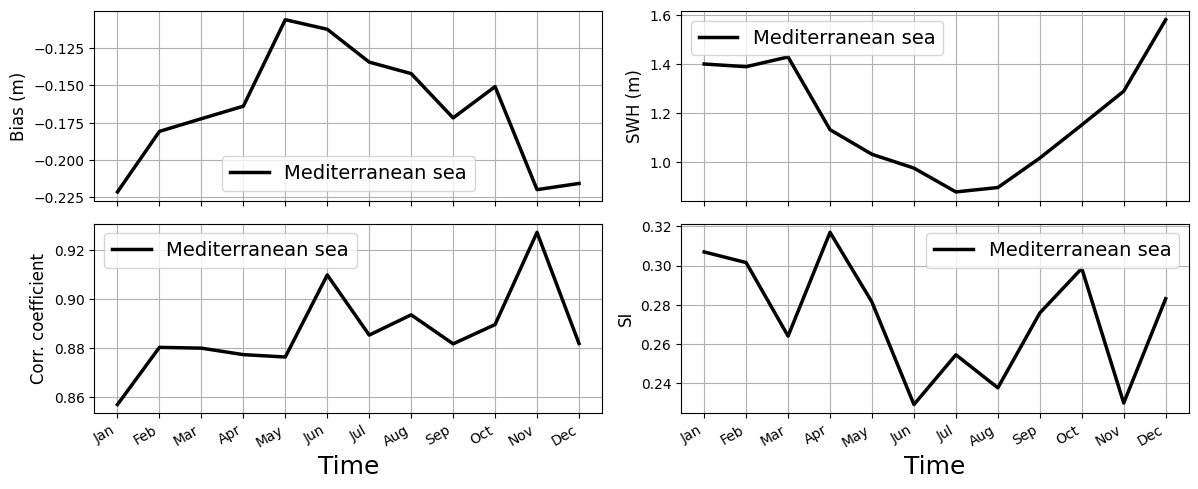

In [ ]:
import calendar

BIAS = np.zeros((5,12))
CORR = np.zeros((5,12))
SI = np.zeros((5,12))
RMSE = np.zeros((5,12))
SWH = np.zeros((5,12))

months = ['2020-01', '2020-02', '2020-03', '2020-04', '2020-05', 
          '2020-06', '2020-07', '2020-08', '2020-09', '2020-10', 
          '2020-11', '2020-12']

months_plot = range(1, 13)
month_labels = [calendar.month_abbr[m] for m in months_plot]

for j in range(0,1):
    # read matched data
    df = pd.read_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Altimeter evaluation//datasets//no_cur//matched_dataset_no_cur (Med).csv")
    df = df[df["value_qc"] == 1]
    
    # convert timestamps to pandas datetime format
    df['time'] = pd.to_datetime(df['time'])

    for i in range(0,12):
        df_months = df[df['time'].dt.to_period('M') == months[i]]

        m = df_months["hs_model_no_cur"].values
        k = df_months["hs_altimeter"].values

        RMSE[j][i] = np.sqrt(np.mean((m - k) ** 2))
        BIAS[j][i] = np.mean(m - k)
        CORR[j][i] = np.corrcoef(m, k)[0, 1]
        SI[j][i]   = np.std(k - m) / np.mean(k)
        SWH[j][i] = np.mean(k)


fig, axes = plt.subplots(2,2,figsize=(12,5))
axes = axes.flatten()  # flatten to a 1D array of length 10
ax1, ax2, ax3, ax4 = axes

#fig.suptitle(f'Statistics ({Region_plots})', x=0.5,y=0.96, 
#            ha='center',fontsize = 14)
plt.rcParams.update({"axes.titlesize": 9,"axes.labelsize": 14})

ax1.plot(months_plot, BIAS[0], linestyle='solid', label="Mediterranean sea", 
         color='black',linewidth = "2.5")
style_axis(ax1, month_labels, months_plot, ylabel="Bias (m)")

ax2.plot(months_plot, SWH[0], linestyle='solid', label="Mediterranean sea", 
         color='black',linewidth = "2.5")
style_axis(ax2, month_labels, months_plot, ylabel="SWH (m)")

ax3.plot(months_plot, CORR[0], linestyle='solid', label="Mediterranean sea", 
         color='black',linewidth = "2.5")
style_axis(ax3, month_labels, months_plot, ylabel="Corr. coefficient")

ax4.plot(months_plot, SI[0], linestyle='solid', label="Mediterranean sea", 
         color='black',linewidth = "2.5")
style_axis(ax4, month_labels, months_plot, ylabel="SI")

# 2. Use AutoDateLocator to avoid too many labels
locator = mdates.AutoDateLocator(minticks=15, maxticks=20)

# Let matplotlib automatically choose tick spacing
fig.autofmt_xdate()

plt.tight_layout()
plt.show()


Monthly table of validation metrics (merged altimeter matched dataset - Mediterranean sea)

In [23]:
import calendar

BIAS = np.zeros((5,12))
CORR = np.zeros((5,12))
SI = np.zeros((5,12))
RMSE = np.zeros((5,12))
SWH = np.zeros((5,12))

months = pd.period_range('2020-01', '2020-12', freq='M')

# read matched data
df = pd.read_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Altimeter evaluation//datasets//no_cur//matched_dataset_no_cur (Mediterranean sea).csv")
df = df[df["value_qc"] == 1]

# convert timestamps to pandas datetime format
df['time'] = pd.to_datetime(df['time'])

for i in range(0,12):
    df_months = df[df['time'].dt.to_period('M') == months[i]]

    m = df_months["hs_model_no_cur"].values
    k = df_months["hs_altimeter"].values

    RMSE[j][i] = np.sqrt(np.mean((m - k) ** 2))
    BIAS[j][i] = np.mean(m - k)
    CORR[j][i] = np.corrcoef(m, k)[0, 1]
    SI[j][i]   = np.std(k - m) / np.mean(k)
    SWH[j][i] = np.mean(k)

df_months_table = pd.DataFrame({'Bias':BIAS[0,:], 'RMSE':RMSE[0,:], 'CORR':CORR[0,:], 'SI':SI[0,:]}, 
                  index=months)
df_months_table


,Bias,RMSE,CORR,SI
2020-01,-0.221316,0.483561,0.856879,0.306982
2020-02,-0.180766,0.456368,0.880269,0.301573
2020-03,-0.172262,0.414994,0.879944,0.264132
2020-04,-0.163870,0.394391,0.877295,0.316973
2020-05,-0.105926,0.308874,0.876320,0.281411
2020-06,-0.112346,0.250064,0.909880,0.229245
2020-07,-0.134346,0.260597,0.885293,0.254601
2020-08,-0.142058,0.255870,0.893572,0.237762
2020-09,-0.171723,0.328618,0.881707,0.275892
2020-10,-0.150767,0.375391,0.889591,0.298604


Validation table against altimeter observations in sub-regions of the Mediterranean sea

In [24]:
import calendar

BIAS = np.zeros(16)
CORR = np.zeros(16)
SI = np.zeros(16)
RMSE = np.zeros(16)
MEAN_M = np.zeros(16)
STD_M = np.zeros(16)
MEAN_A = np.zeros(16)
STD_A = np.zeros(16)

Regions = {
    "Mediterranean sea":      {"i":0,"lon_min": -10,  "lon_max": 37, "lat_min": 30, "lat_max": 48},
    "Eastern Mediterranean sea":      {"i":1, "lon_min": 11,  "lon_max": 37, "lat_min": 30, "lat_max": 48},
    "Western Mediterranean sea":      {"i":2, "lon_min": -10,  "lon_max": 11, "lat_min": 30, "lat_max": 48},
    "Levantine":   {"i":3, "lon_min": 19.5,  "lon_max": 36.5,   "lat_min": 30.5, "lat_max": 37.5},
    "Algeria current":    {"i":4, "lon_min": -1,  "lon_max": 9.8, "lat_min": 35, "lat_max": 40},    
    "Ionian":      {"i":5, "lon_min": 15,  "lon_max": 23.5, "lat_min": 36, "lat_max": 40},
    "Aegean":      {"i":6, "lon_min": 22,"lon_max": 28,   "lat_min": 35.5, "lat_max": 41},
    "Adriatic":    {"i":7, "lon_min": 12,  "lon_max": 19.5, "lat_min": 40, "lat_max": 46},    
    "Alboran":    {"i":8, "lon_min": -6,  "lon_max": -1, "lat_min": 35, "lat_max": 37},
    "Gulf of Sidra": {"i":9, "lon_min": 15,  "lon_max": 20, "lat_min": 30, "lat_max": 32.5},
    "Sicily":    {"i":10, "lon_min": 9.5,  "lon_max": 16, "lat_min": 32, "lat_max": 38.2},
    "central_med":    {"i":11, "lon_min": 16,  "lon_max": 22, "lat_min": 32, "lat_max": 36},
    "Tyrrhenian sea": {"i":12, "lon_min": 8.5,  "lon_max": 16, "lat_min": 37.5, "lat_max": 43.5},
    "Ligurian":    {"i":13, "lon_min": 6.5,  "lon_max": 11, "lat_min": 42, "lat_max": 44.5},
    "Gulf of Lions":    {"i":14, "lon_min": 3,  "lon_max": 6.5, "lat_min": 42, "lat_max": 44},
    "Balearic":    {"i":15, "lon_min": -1,  "lon_max": 8.5, "lat_min": 38, "lat_max": 42}    
    }

for name, r in Regions.items():
    df_all = pd.read_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Altimeter evaluation//datasets//no_cur//matched_dataset_no_cur (Mediterrenean sea).csv")
    df_all = df_all[df_all["value_qc"] == 1]
    df_all = df_all[
        (df_all.longitude >= r["lon_min"]) &
        (df_all.longitude <= r["lon_max"]) &
        (df_all.latitude  >= r["lat_min"]) &
        (df_all.latitude  <= r["lat_max"])
    ]

    # read parameters from matched datasets
    x = df_all['hs_altimeter'].values
    y = df_all['hs_model_no_cur'].values

    # ------------------------------------
    # Apply percentile filtering
    # ------------------------------------
    bounds_hs_var1,_ = adaptive_percentile_range(x)
    min_hs_var1, max_hs_var1 = bounds_hs_var1

    bounds_hs_var2,_ = adaptive_percentile_range(y)
    min_hs_var2, max_hs_var2 = bounds_hs_var2

    mask = (
        (x >= min_hs_var1) & (x <= max_hs_var1) &
        (y >= min_hs_var2) & (y <= max_hs_var2)
    )

    a = x[mask]
    b = y[mask]

    BIAS[r["i"]] = np.round(np.mean(b - a), 2)
    CORR[r["i"]] = np.round(np.corrcoef(b, a)[0][1],2)
    SI[r["i"]] = np.round(np.std(a - b) / np.mean(a),2)
    RMSE[r["i"]] = np.round(np.sqrt(((b - a) ** 2).mean()),2)
    MEAN_M[r["i"]] = np.round(np.mean(b), 2)
    STD_M[r["i"]] = np.round(np.std(b), 2)
    MEAN_A[r["i"]] = np.round(np.mean(a), 2)
    STD_A[r["i"]] = np.round(np.std(a), 2)

df = pd.DataFrame({'Mean_A':MEAN_A, 'Mean_M':MEAN_M, 'STD_A':STD_A, 'STD_M': STD_M,
                   'Bias':BIAS, 'RMSE':RMSE, 'CORR':CORR, 'SI':SI}, 
                  index=Regions.keys())
df

,Mean_A,Mean_M,STD_A,STD_M,Bias,RMSE,CORR,SI
Mediterranean sea,1.09,0.95,0.52,0.48,-0.14,0.29,0.87,0.24
Eastern Mediterranean sea,1.06,0.95,0.48,0.46,-0.11,0.23,0.91,0.19
Western Mediterranean sea,1.16,0.94,0.60,0.51,-0.22,0.43,0.79,0.32
Levantine,1.08,0.98,0.44,0.43,-0.10,0.23,0.89,0.19
Algeria current,1.07,0.98,0.56,0.53,-0.10,0.22,0.94,0.18
Ionian,1.03,0.89,0.47,0.48,-0.14,0.24,0.92,0.19
Aegean,0.97,0.86,0.44,0.47,-0.11,0.25,0.88,0.23
Adriatic,0.93,0.71,0.48,0.43,-0.22,0.34,0.85,0.27
Alboran,0.96,0.89,0.43,0.44,-0.07,0.21,0.89,0.21
Gulf of Sidra,1.06,0.97,0.50,0.43,-0.09,0.21,0.93,0.17


Timeseries of validation metrics (buoys merged matched data)

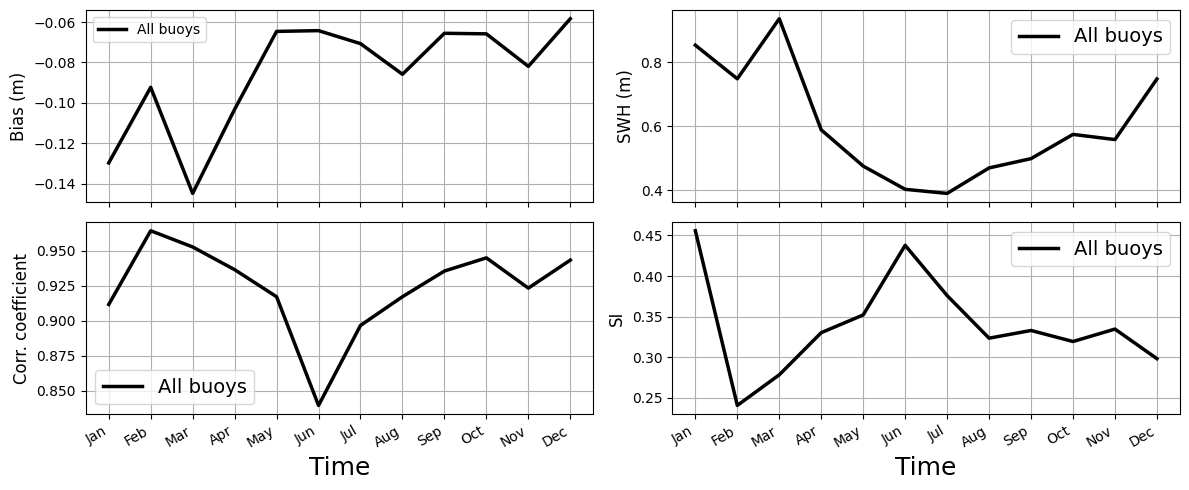

In [25]:
import calendar

BIAS = np.zeros((5,12))
CORR = np.zeros((5,12))
SI = np.zeros((5,12))
RMSE = np.zeros((5,12))
SWH = np.zeros((5,12))

Platforms_list = ['','ADN-DWRG1', 'Malaga-coast-buoy', 'Melilla-coast-buoy', 
                  'MYKON']

months = ['2020-01', '2020-02', '2020-03', '2020-04', '2020-05', 
          '2020-06', '2020-07', '2020-08', '2020-09', '2020-10', 
          '2020-11', '2020-12']


months_plot = range(1, 13)
month_labels = [calendar.month_abbr[m] for m in months_plot]

#for j in range(0,len(Platforms_list)):
for j in range(0,1):
    if j == 0:
        # read matched dataset
        df = pd.read_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Buoys evaluation//complete_matched_datasets//no_cur//matched_dataset_no_cur (Med).csv")
        df = df[df["value_qc"] == 1]
        df['time'] = pd.to_datetime(df['time'])
        for i in range(0,12):
            df_months = df[df['time'].dt.to_period('M') == months[i]]

            # read parameters of matched dataset
            m = df_months["hs_model_no_cur"].values
            k = df_months["hs_buoys"].values

            RMSE[j][i] = np.sqrt(np.mean((m - k) ** 2))
            BIAS[j][i] = np.mean(m - k)
            CORR[j][i] = np.corrcoef(m, k)[0, 1]
            SI[j][i]   = np.std(k - m) / np.mean(k)
            SWH[j][i] = np.mean(k)
    else:
        # read matched dataset
        df = pd.read_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Buoys evaluation//complete_matched_datasets//no_cur//matched_dataset_no_cur (Med).csv")
        df = df[df["value_qc"] == 1]
        # select specific platform
        df = df[df["platform_id"] == Platforms_list[j]]

        # convert timestamps to pandas datetime format
        df['time'] = pd.to_datetime(df['time'])

        for i in range(0,12):
            df_months = df[df['time'].dt.to_period('M') == months[i]]

            k = df_months["hs_model_no_cur"].values
            m = df_months["hs_buoys"].values

            RMSE[j][i] = np.sqrt(np.mean((m - k) ** 2))
            BIAS[j][i] = np.mean(m - k)
            #mae_no[i]  = np.mean(np.abs(m - k))
            CORR[j][i] = np.corrcoef(m, k)[0, 1]
            SI[j][i]   = np.std(k - m) / np.mean(k)

fig, axes = plt.subplots(2,2,figsize=(12,5))
axes = axes.flatten()  # flatten to a 1D array of length 10
ax1, ax2, ax3, ax4 = axes

#fig.suptitle(f'Statistics ({Region_plots})', x=0.5,y=0.96, 
#            ha='center',fontsize = 14)
plt.rcParams.update({"axes.titlesize": 9,"axes.labelsize": 14})


ax1.plot(months_plot, BIAS[0], linestyle='solid', label="All buoys", 
         color='black',linewidth = "2.5")
"""ax1.plot(months_plot, BIAS[1], linestyle='--', label="ADN-DWRG1", 
         color='blue',linewidth = "1.5")
ax1.plot(months_plot, BIAS[2], linestyle='--', label="Malaga-coast-buoy", 
         color='red', linewidth = "1.5")
ax1.plot(months_plot, BIAS[3], linestyle='--', label="Melilla-coast-buoy", 
         color='yellow', linewidth = "1.5")
ax1.plot(months_plot, BIAS[4], linestyle='--', label="MYKON", 
         color='green',linewidth = "1.5")"""
#ax1.set_ylim([-0.3, 0.3])
style_axis(ax1, month_labels, months_plot, ylabel="Bias (m)")
ax1.legend(loc='upper left', ncol=1)

ax2.plot(months_plot, SWH[0], linestyle='solid', label="All buoys", 
         color='black',linewidth = "2.5")
"""ax2.plot(months_plot, RMSE[1], linestyle='--', label="ADN-DWRG1", 
         color='blue',linewidth = "1.5")
ax2.plot(months_plot, RMSE[2], linestyle='--', label="Malaga-coast-buoy", 
         color='red', linewidth = "1.5")
ax2.plot(months_plot, RMSE[3], linestyle='--', label="Melilla-coast-buoy", 
         color='yellow', linewidth = "1.5")
ax2.plot(months_plot, RMSE[4], linestyle='--', label="MYKON", 
         color='green',linewidth = "1.5")"""
#ax2.set_ylim([-0.5, 0.5])
style_axis(ax2, month_labels, months_plot, ylabel="SWH (m)")

ax3.plot(months_plot, CORR[0], linestyle='solid', label="All buoys", 
         color='black',linewidth = "2.5")
"""ax3.plot(months_plot, CORR[1], linestyle='--', label="ADN-DWRG1", 
         color='blue',linewidth = "3.5")
ax3.plot(months_plot, CORR[2], linestyle='--', label="Malaga-coast-buoy", 
         color='red', linewidth = "1.5")
ax3.plot(months_plot, CORR[3], linestyle='--', label="Melilla-coast-buoy", 
         color='yellow', linewidth = "1.5")
ax3.plot(months_plot, CORR[4], linestyle='--', label="MYKON", 
         color='green',linewidth = "1.5")"""
#ax3.set_ylim(0.6,1)
style_axis(ax3, month_labels, months_plot, ylabel="Corr. coefficient")

ax4.plot(months_plot, SI[0], linestyle='solid', label="All buoys", 
         color='black',linewidth = "2.5")
"""ax4.plot(months_plot, SI[1], linestyle='--', label="ADN-DWRG1", 
         color='blue',linewidth = "1.5")
ax4.plot(months_plot, SI[2], linestyle='--', label="Malaga-coast-buoy", 
         color='red', linewidth = "1.5")
ax4.plot(months_plot, SI[3], linestyle='--', label="Melilla-coast-buoy", 
         color='yellow', linewidth = "1.5")
ax4.plot(months_plot, SI[4], linestyle='--', label="MYKON", 
         color='green',linewidth = "1.5")"""
style_axis(ax4, month_labels, months_plot, ylabel="SI")

# 2. Use AutoDateLocator to avoid too many labels
locator = mdates.AutoDateLocator(minticks=15, maxticks=20)

# Let matplotlib automatically choose tick spacing
fig.autofmt_xdate()

plt.tight_layout()
plt.show()


Validation tables against merged buoys matched dataset

In [26]:
import calendar

BIAS = np.zeros((5,12))
CORR = np.zeros((5,12))
SI = np.zeros((5,12))
RMSE = np.zeros((5,12))
SWH = np.zeros((5,12))

Platforms_list = ['','ADN-DWRG1', 'Malaga-coast-buoy', 'Melilla-coast-buoy', 
                  'MYKON']

months = pd.period_range('2020-01', '2020-12', freq='M')
months_plot = range(1, 13)
month_labels = [calendar.month_abbr[m] for m in months_plot]

for j in range(0,1):
    if j == 0:
        # read matched dataset
        df = pd.read_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Buoys evaluation//complete_matched_datasets//no_cur//matched_dataset_no_cur (Med).csv")
        df = df[df["value_qc"] == 1]
        
        # convert timestamps to pandas datetime format
        df['time'] = pd.to_datetime(df['time'])
        for i in range(0,12):
            df_months = df[df['time'].dt.to_period('M') == months[i]]

            m = df_months["hs_model_no_cur"].values
            k = df_months["hs_buoys"].values

            RMSE[j][i] = np.sqrt(np.mean((m - k) ** 2))
            BIAS[j][i] = np.mean(m - k)
            CORR[j][i] = np.corrcoef(m, k)[0, 1]
            SI[j][i]   = np.std(k - m) / np.mean(k)
            SWH[j][i] = np.mean(k)
    else:
        # read matched dataset
        df = pd.read_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Buoys evaluation//complete_matched_datasets//no_cur//matched_dataset_no_cur (Med).csv")
        df = df[df["value_qc"] == 1]
        # select specific platform
        df = df[df["platform_id"] == Platforms_list[j]]
        df['time'] = pd.to_datetime(df['time'])
        for i in range(0,12):
            df_months = df[df['time'].dt.to_period('M') == months[i]]

            k = df_months["hs_model_no_cur"].values
            m = df_months["hs_buoys"].values

            RMSE[j][i] = np.sqrt(np.mean((m - k) ** 2))
            BIAS[j][i] = np.mean(m - k)
            CORR[j][i] = np.corrcoef(m, k)[0, 1]
            SI[j][i]   = np.std(k - m) / np.mean(k)

df_months_table = pd.DataFrame({'Bias':BIAS[0,:], 'RMSE':RMSE[0,:], 'CORR':CORR[0,:], 'SI':SI[0,:]}, 
                  index=months)
df_months_table


,Bias,RMSE,CORR,SI
2020-01,-0.129785,0.410217,0.911565,0.455795
2020-02,-0.092334,0.202362,0.964100,0.240550
2020-03,-0.144888,0.298225,0.952548,0.278277
2020-04,-0.103220,0.220068,0.936381,0.330235
2020-05,-0.064623,0.179321,0.917090,0.352036
2020-06,-0.064251,0.187545,0.839672,0.437841
2020-07,-0.070685,0.162607,0.896638,0.375907
2020-08,-0.085872,0.174415,0.917115,0.323405
2020-09,-0.065560,0.178451,0.935384,0.332918
2020-10,-0.065837,0.194870,0.944789,0.319302


Validation table per buoy platform

In [27]:
BIAS = np.zeros(11)
CORR = np.zeros(11)
SI = np.zeros(11)
RMSE = np.zeros(11)
MEAN_M = np.zeros(11)
STD_M = np.zeros(11)
MEAN_B = np.zeros(11)
STD_B = np.zeros(11)

Platforms_list = ['All buoys','ADN-DWRG1', 'OBSEA', '6100021', 'Malaga-coast-buoy', 
                  'Melilla-coast-buoy', 'Kariani', 'ATHOS',
                  'MYKON', 'HERAKLION', '61499']

for i in range(len(Platforms_list)):
    if i == 0 :
        # read matched dataset
        df = pd.read_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Buoys evaluation//complete_matched_datasets//no_cur//matched_dataset_no_cur (Med).csv")
        df = df[df["value_qc"] == 1]

        # ------------------------------------
        # Apply percentile filtering
        # ------------------------------------
        x = df['hs_buoys'].values
        y = df['hs_model_no_cur'].values
        bounds_hs_var1,_ = adaptive_percentile_range(x)
        min_hs_var1, max_hs_var1 = bounds_hs_var1

        bounds_hs_var2,_ = adaptive_percentile_range(y)
        min_hs_var2, max_hs_var2 = bounds_hs_var2

        mask = (
            (x >= min_hs_var1) & (x <= max_hs_var1) &
            (y >= min_hs_var2) & (y <= max_hs_var2)
        )

        a = x[mask]
        b = y[mask]

        BIAS[i] = np.mean(b - a)
        CORR[i] = np.corrcoef(b, a)[0][1]
        SI[i] = np.std(a - b) / np.mean(a)
        RMSE[i] = np.sqrt(((b - a) ** 2).mean())
        MEAN_M[i] = np.mean(b)
        STD_M[i] = np.std(b)
        MEAN_B[i] = np.mean(a)
        STD_B[i] = np.std(a)
    else:    
        # read matched dataset
        df = pd.read_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Buoys evaluation//complete_matched_datasets//no_cur//matched_dataset_no_cur (Med).csv")
        df = df[df["value_qc"] == 1]
        # select specific platform
        df_platforms = df[df["platform_id"] == Platforms_list[i]]
        x = df_platforms['hs_buoys']
        y = df_platforms['hs_model_no_cur']

        # ------------------------------------
        # Apply percentile filtering
        # ------------------------------------
        bounds_hs_var1,_ = adaptive_percentile_range(x)
        min_hs_var1, max_hs_var1 = bounds_hs_var1

        bounds_hs_var2,_ = adaptive_percentile_range(y)
        min_hs_var2, max_hs_var2 = bounds_hs_var2

        mask = (
            (x >= min_hs_var1) & (x <= max_hs_var1) &
            (y >= min_hs_var2) & (y <= max_hs_var2)
        )

        a = x[mask]
        b = y[mask]

        BIAS[i] = np.mean(b - a)
        CORR[i] = np.corrcoef(b, a)[0][1]
        SI[i] = np.std(a - b) / np.mean(a)
        RMSE[i] = np.sqrt(((b - a) ** 2).mean())
        MEAN_M[i] = np.mean(b)
        STD_M[i] = np.std(b)
        MEAN_B[i] = np.mean(a)
        STD_B[i] = np.std(a)

df = pd.DataFrame({'Mean_B':MEAN_B, 'Mean_M':MEAN_M, 'STD_B':STD_B, 'STD_M': STD_M,
    'Bias':BIAS, 'RMSE':RMSE, 'CORR':CORR, 'SI':SI}, 
                  index=Platforms_list)
df


,Mean_B,Mean_M,STD_B,STD_M,Bias,RMSE,CORR,SI
All buoys,0.511185,0.432616,0.365407,0.353324,-0.078569,0.184298,0.892932,0.326127
ADN-DWRG1,0.333159,0.237898,0.252859,0.236827,-0.095261,0.161986,0.858828,0.393251
OBSEA,0.583668,0.501849,0.253368,0.282345,-0.081818,0.155168,0.884373,0.225889
6100021,0.976082,0.904556,0.579346,0.566950,-0.071526,0.227984,0.928900,0.221778
Malaga-coast-buoy,0.377783,0.256672,0.219679,0.188127,-0.121111,0.181900,0.789196,0.359250
Melilla-coast-buoy,0.475912,0.487154,0.346854,0.293723,0.011241,0.148088,0.906847,0.310268
Kariani,0.416815,0.325082,0.175028,0.197954,-0.091733,0.194180,0.584884,0.410604
ATHOS,0.657606,0.613397,0.503621,0.501390,-0.044210,0.191560,0.931220,0.283434
MYKON,0.980073,0.856956,0.656562,0.664854,-0.123117,0.237843,0.952645,0.207636
HERAKLION,0.685250,0.452173,0.356357,0.269034,-0.233077,0.316597,0.800342,0.312679


Validation metrics per buoy platform

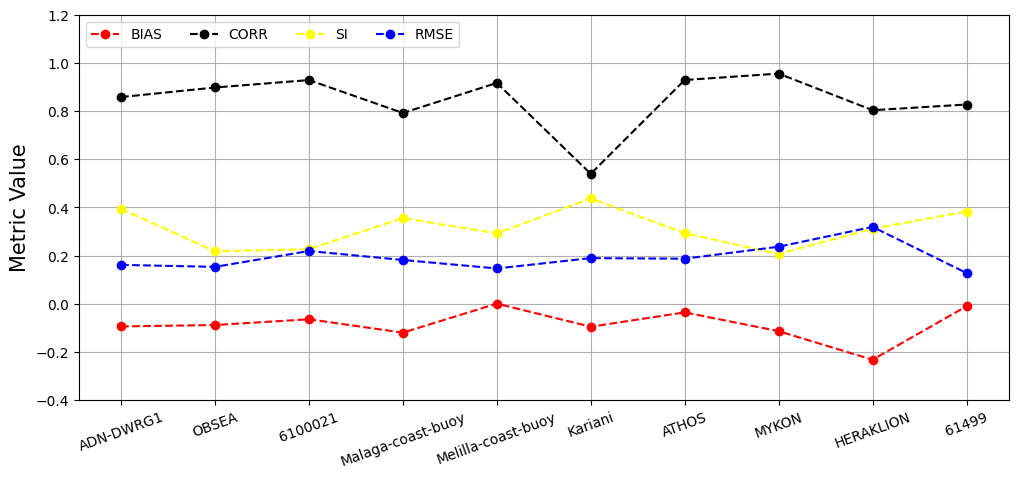

In [11]:
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(Platforms_list[1:], BIAS[1:], linestyle = 'dashed', marker = 'o', color='red',
         label="BIAS", linewidth=1.5)

ax.plot(Platforms_list[1:], CORR[1:], linestyle = 'dashed', marker = 'o', color='black',
         label="CORR", linewidth=1.5)

ax.plot(Platforms_list[1:], SI[1:], linestyle = 'dashed', marker = 'o', color='yellow',
         label="SI", linewidth=1.5)

ax.plot(Platforms_list[1:], RMSE[1:], linestyle = 'dashed', marker = 'o', color='blue',
         label="RMSE", linewidth=1.5)

plt.xticks(rotation=20)

ax.set_ylabel("Metric Value", fontsize=15)
ax.set_ylim([-0.4, 1.2])
ax.grid(True)
plt.legend(bbox_to_anchor=(0, 1), loc='upper left', ncol=4, frameon=True)

Sea State Bias (SSB)

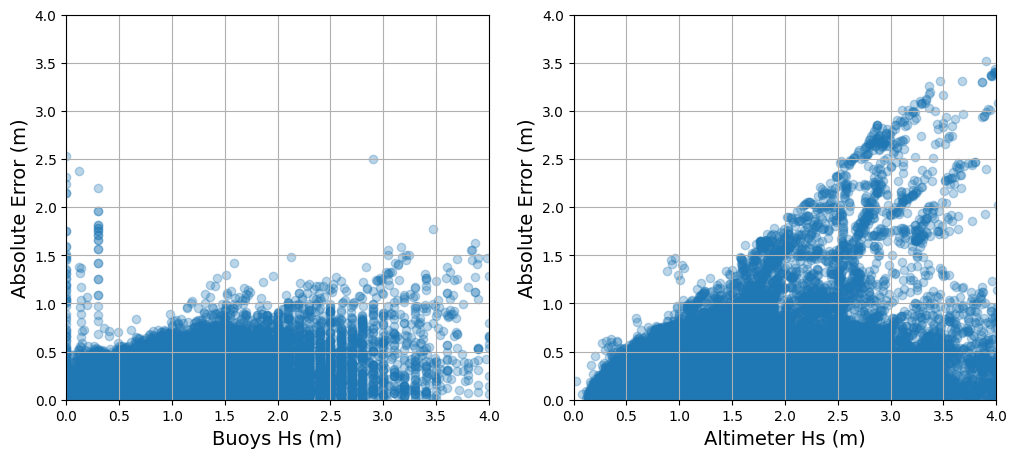

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(12,5))
axes = axes.flatten()  # flatten to a 1D array of length 10
ax1, ax2 = axes

# Buoys dataset
df = pd.read_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Buoys evaluation//complete_matched_datasets//no_cur//matched_dataset_no_cur (Med).csv")
df = df[df["value_qc"] == 1]

# Altimeter dataset
df_all = pd.read_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Altimeter evaluation//datasets//no_cur//matched_dataset_no_cur (Mediterrenean sea).csv")
df_all = df_all[df_all["value_qc"] == 1]

#fig.suptitle(f'Statistics ({Region_plots})', x=0.5,y=0.96, 
#            ha='center',fontsize = 14)
plt.rcParams.update({"axes.titlesize": 9,"axes.labelsize": 14})

ax1.scatter(df["hs_buoys"], abs(df["hs_model_no_cur"] - df["hs_buoys"]), alpha=0.3)
ax1.set_xlim(0,4)
ax1.set_ylim(0,4)
ax1.set_xlabel("Buoys Hs (m)")
ax1.set_ylabel("Absolute Error (m)")
ax1.grid(True)

ax2.scatter(df_all["hs_altimeter"], abs(df_all["hs_model_no_cur"] - df_all["hs_altimeter"]), alpha=0.3)
ax2.set_xlim(0,4)
ax2.set_ylim(0,4)
ax2.set_xlabel("Altimeter Hs (m)")
ax2.set_ylabel("Absolute Error (m)")
ax2.grid(True)

Scatter plots (monthly altimeter matched dataset)

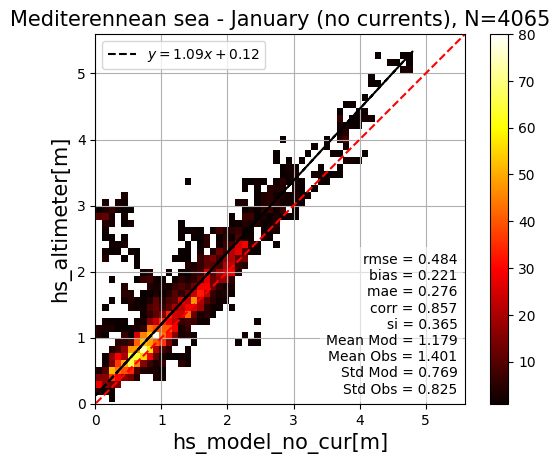

In [22]:
for i in range(0,1):
   plot_scatter(df_months_no_cur[i], var1='hs_model_no_cur', var2='hs_altimeter', annotation_position='bottom-right',
   var1_units='m',
   var2_units='m',
   title=f'{Region_plots} - {Months_list[i]} (no currents)',
   regression_line='effective-variance',
   qqplot=False,
   density=True,
   output_file=f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Altimeter evaluation//Scatter_plots//no_cur//monthly//scatter_plot_no_cur ({Region_saves}, {Months_list[i]}).png")


In [ ]:
for i in range(0,12):
   plot_scatter(df_months_with_cur[i], var1='hs_model_with_cur', var2='hs_altimeter', annotation_position='bottom-right',
   var1_units='m',
   var2_units='m',
   title=f'{Region_plots} - {Months_list[i]} (with currents)',
   regression_line='effective-variance',
   qqplot=False,
   density=True,
   output_file=f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Altimeter evaluation//Scatter_plots//with_cur//monthly//scatter_plot_with_cur ({Region_saves}, {Months_list[i]}).png")
